In [19]:
#Importar librerias
import PIL.Image as img
from bitstring import BitArray
from win32comext import bits
import tkinter as tk
from tkinter import filedialog, messagebox, simpledialog
from PIL import ImageTk

# Desafio bitwise operators

In [20]:
class Imagen:
    def __init__(self, nombre_archivo):
        '''
        Inicializar la clase Imagen, cargando una imagen desde la carpeta del proyecto y guardando su width height y pixeles
        '''
        try:
            self.image = img.open(nombre_archivo)
        except AttributeError:
            self.image = nombre_archivo
        self.pixels = self.image.load()
        self.width, self.height = self.image.size
        return
    
    def show(self):
        self.image.show()
    
    def encode(self, msg, partes):
        '''
        Funcion que codifica un mensaje dentro de una imagen, retornando una copia modificada de la original.
        La idea es copiar el mensaje a toda la foto. 
        Parametros:

        self: imagen

        msg: mensaje a codificar

        partes: partes a dividir el mensaje codificado. "Cada cuantos bits guardamos una letra?"
        Valores aceptados serian 3, 6 y 8.
        3 partes = guardar cada letra en 1 color
        6 partes = guardar cada letra en 2 colores
        8 partes = guardar cada letra en 3 colores
        
        '''
        newimg = self.image.copy()

        msg += chr(0)
        
        bits = BitArray(bytes=msg.encode('utf-8')).bin
        
        bit_index = 0
        for x in range(self.width):
            for y in range(self.height):
                if bit_index >= len(bits):
                    break
                
                r, g, b = newimg.getpixel((x, y)) # Obtiene valores RGB
                
                if partes >= 3 and bit_index < len(bits):
                    r = (r >> 1 << 1) | (ord(bits[bit_index]) & 1) # hace que el ultimo bit sea 0 | convierte int en ASCII, retorna valor basado en & 
                    bit_index += 1
                
                if partes >= 6 and bit_index < len(bits):
                    g = (g >> 1 << 1) | (ord(bits[bit_index]) & 1)
                    bit_index += 1
                
                if partes == 8 and bit_index < len(bits):
                    b = (b >> 1 << 1) | (ord(bits[bit_index]) & 1)
                    bit_index += 1
                
                newimg.putpixel((x, y), (r, g, b))
            
            if bit_index >= len(bits):
                print("MENSAJE COMPLETADO")
                break
    
        return Imagen(newimg) # la copia modificada
    
    def decode(self, partes):
        '''
        Funcion que decodifica el mensaje de una imagen. 
        Itera sobre la imagen, luego identifica en que canales tiene que trabajar basado en las partes.
        3 partes = R
        6 partes = R, G
        8 partes = R, G, B
        '''
        extracted_bits = ""
        msgBytes = bytearray()
        for x in range(self.width):
            for y in range(self.height):
                r, g, b = self.image.getpixel((x, y))
                channels = [] # lista de canales. Se reinicia a una lista vacia al inicio de cada loop de x, y
                # Chequeamos que partes tienen 
                if partes >= 3:
                    channels.append(r)
                if partes >= 6:
                    channels.append(g)
                if partes == 8:
                    channels.append(b)
                for i in channels:
                    extracted_bits += str(i & 1) # Extraemos los bits: si hay 3 canales, extraemos r, g, b, 2 canales r, g, 1 canal r
                    if len(extracted_bits) == 8: # extraemos el byte
                        byte = int(extracted_bits, 2) # interpretamos el byte obtenido como un numero base 2
                        if byte == 0:
                            return msgBytes.decode(encoding= "utf-8")
                        # si no encuentra el final, procede a agregar al mensaje
                        msgBytes.append(byte)
                        extracted_bits = "" # reiniciar valor
                    
        return msgBytes.decode(encoding="utf-8")
                

    
    def __ne__(self, other):
        '''
        Compara dos imagenes basado en varias condiciones. Toma como parametros:
        self: imagen 1 a comparar
        other: imagen 2 a comparar
        Valores posibles retornados: True o False
        Primero, se hace una comparacion de width/height simple. Si son diferentes, retorna True.
        Luego, revisamos cada pixel individualmente por medio de .getpixel(). Si existe diferencia, retornamos True.
        Si no hay diferencia, retornamos False.
        '''
        # verificar dimensiones
        if self.width != other.width or self.height != other.height:
            return True
    
        for x in range(self.width):
            for y in range(self.height):
                if self.image.getpixel((x, y)) != other.image.getpixel((x, y)): # si se encuentra una diferencia en pixel...
                    return True 
        else:
            return False
        
    def save(self, nombreArchivo):
        '''Guarda la imagen de un archivo como nombreArchivo.
        nombreArchivo: Debe terminar en .png
        '''
        try:
            self.image.save(nombreArchivo)
            print("Imagen guardada")
        except Exception as e:
            print(f"Error {e} al guardar imagen.")

## Funcion en accion

In [21]:
i1 = Imagen("tuxy.png")
i2 = i1.encode("Profesor me podria por favor entregar una nota siete en este trabajo muchas gracias", 3) # encode, 3 partes

MENSAJE COMPLETADO


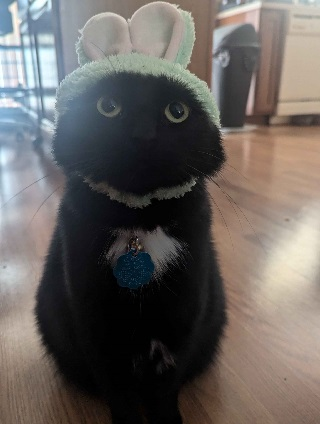

'Profesor me podria por favor entregar una nota siete en este trabajo muchas gracias'

In [22]:
display(i2.image)
i2.decode(3)

Verificar si las imagenes de verdad no son iguales:

In [23]:
i1.__ne__(i2)

True

In [24]:
i1.__ne__(i1)

False

### Tarea adicional: UI para poder ingresar archivos y codificar/decodificar usando tkinter y PIL

### Como usar la aplicacion?

1. Cargue imagen
2. Codifique imagen, ingresando numero de partes. Se guardara a un archivo
3. Cargue imagen codificada
4. Decodifique imagen, ingresando numero de partes.
5. Obtendra el mensaje!

HINT: sebaCodificado usa 8 partes

Usaremos una clase para esto:

In [ ]:
class EncodeUI:
    '''
    Objeto creado con tkinter que contiene todas las funciones de la tarea.
    init: inicializa la funcion, contiene parametros de geometria, UI basica, y botones a luego programar con funciones, ademas de agregar funcion de previsualizacion
    loadImage: Carga imagen desde sistema
    msgEncode: Codifica imagen. Pide mensaje y partes de mensaje
    msgDecode: Decodifica imagen. Pide partes de mensaje
    '''
    def __init__(self, root):
        self.root = root
        self.root.title("Herramienta de codificacion/decodificacion LSB")
        self.root.geometry("1024x720")
        self.root.configure(padx=25, pady=25)

        self.current_obj = None  # To store the Imagen instance

        # UI
        tk.Label(self.root, text="Herramienta de codificacion/decodificacion LSB", font=("Arial", 25, "bold")).pack(pady=10) # Titulo de herramienta
        
        self.status_label = tk.Label(self.root, text="No se ha cargado una imagen", fg="red") # Default
        self.status_label.pack(pady=5)

        tk.Button(self.root, text="1. Cargar Imagen", width=25, command=self.loadImage).pack(pady=5) # Cargar imagen para codificar/decodificar
        
        self.btn_encode = tk.Button(self.root, text="Codificar mensaje", width=25, 
                                    state="disabled", command=self.msgEncode) 
        self.btn_encode.pack(pady=5)
        
        self.btn_decode = tk.Button(self.root, text="Decodificar mensaje", width=25, 
                                    state="disabled", command=self.msgDecode)
        self.btn_decode.pack(pady=5)

        # Previsualizar imagen 
        self.canvas = tk.Label(self.root, text="[ Previsualizacion Imagen ]", bg="lightgrey", width=40, height=10)
        self.canvas.pack(pady=20)

    def loadImage(self):
        '''
        Carga imagen para codificar o decodificar.
        file_path: PATH a imagen para codificar/decodificar
        '''
        file_path = filedialog.askopenfilename(filetypes=[("Images", "*.png *")])
        if file_path:
        # Crear instancia de Imagen
            self.current_obj = Imagen(file_path)
            
        # Update UI state
            self.status_label.config(text=f"Imagen cargada: {file_path.split('/')[-1]}")
            self.btn_encode["state"] = "normal"
            self.btn_decode["state"] = "normal"
            self.update_preview()

    def msgEncode(self):
         '''
         Codifica mensaje en imagen.
         msg = Mensaje a ser codificado.
         partes = Numero de partes en el mensaje: 3, 6 o 8. 
         imagenObj = Usa un objeto Imagen cargado con loadImage, y codifica el mensaje usando msg y partes
         savePath = PATH para guardar la imagen. Toma un nombre de archivo en PNG. 
         '''
         msg = simpledialog.askstring("Mensaje", "Ingresa el mensaje secreto:")
         partes = simpledialog.askinteger("Partes", "Ingresa el numero de partes 3, 6 y 8", initialvalue= 8, minvalue=3, maxvalue=8)
         # para partes, askinteger es peor que OptionMenu probablemente... pero askinteger es mas simple y posiblemente usara menos memoria? (soy nuevo con tkinter)

         imagenObj = self.current_obj.encode(msg, partes) # Codifica imagen
         # Para guardar la imagen:
         savePath = filedialog.asksaveasfilename(defaultextension='.png', filetypes=[("PNG File", "*png")])
         imagenObj.save(savePath)
         messagebox.showinfo("Mensaje", "Mensaje codificado")
    
    def msgDecode(self):
         '''
         Decodifica mensaje en imagen.
         partes = Numero de partes en el mensaje: 3, 6 o 8. 
         imagenObj = Usa objeto imagen cargado con loadImage, y decodifica el mensaje usando partes
         '''
         partes = simpledialog.askinteger("Partes", "Ingresa el numero de partes 3, 6 y 8", initialvalue= 8, minvalue=3, maxvalue=8)
         imagenObj = self.current_obj
         msg = imagenObj.decode(partes)
         messagebox.showinfo(f"Mensaje", {msg})

In [26]:
if __name__ == "__main__":
    root = tk.Tk()
    app = EncodeUI(root)
    root.mainloop()

Exception in Tkinter callback
Traceback (most recent call last):
  File "c:\Python311\Lib\tkinter\__init__.py", line 1948, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\Seba RC\AppData\Local\Temp\ipykernel_5904\1318761193.py", line 51, in loadImage
    self.update_preview()
    ^^^^^^^^^^^^^^^^^^^
AttributeError: 'EncodeUI' object has no attribute 'update_preview'


MENSAJE COMPLETADO
Imagen guardada


Exception in Tkinter callback
Traceback (most recent call last):
  File "c:\Python311\Lib\tkinter\__init__.py", line 1948, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\Seba RC\AppData\Local\Temp\ipykernel_5904\1318761193.py", line 79, in msgDecode
    msg = imagenObj.decode(partes)
          ^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Seba RC\AppData\Local\Temp\ipykernel_5904\2197456488.py", line 94, in decode
    return msgBytes.decode(encoding= "utf-8")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 1-2: invalid continuation byte
Exception in Tkinter callback
Traceback (most recent call last):
  File "c:\Python311\Lib\tkinter\__init__.py", line 1948, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\Seba RC\AppData\Local\Temp\ipykernel_5904\1318761193.py", line 51, in loadImage
    self.update_preview()
    ^^^^^^^^^^^^^^^^^^^
AttributeError: 'Encod